In [62]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pmdarima.arima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import warnings
import time
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error
import scipy.stats as stats
from sklearn.neural_network import MLPRegressor

from statsmodels.tsa.stattools import acf
from statsmodels.graphics.gofplots import qqplot
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

In [24]:
df = pd.read_csv('C:\\Users\\windows\\.cache\\kagglehub\\datasets\\mubashirrahim\\wind-power-generation-data-forecasting\\versions\\1\\Location1.csv')
df

,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
0,2017-01-02 00:00:00,28.5,85,24.5,1.44,1.26,146,162,1.4,0.1635
1,2017-01-02 01:00:00,28.4,86,24.7,2.06,3.99,151,158,4.4,0.1424
2,2017-01-02 02:00:00,26.8,91,24.5,1.30,2.78,148,150,3.2,0.1214
3,2017-01-02 03:00:00,27.4,88,24.3,1.30,2.69,58,105,1.6,0.1003
4,2017-01-02 04:00:00,27.3,88,24.1,2.47,4.43,58,84,4.0,0.0793
...,...,...,...,...,...,...,...,...,...,...
43795,2021-12-31 19:00:00,34.1,94,32.5,1.00,1.91,53,137,2.5,0.1796
43796,2021-12-31 20:00:00,34.8,94,33.4,2.52,4.30,56,72,4.8,0.2066
43797,2021-12-31 21:00:00,34.1,95,33.0,1.10,1.84,360,45,4.3,0.2336
43798,2021-12-31 22:00:00,34.4,96,33.5,2.40,4.62,45,51,4.2,0.2606


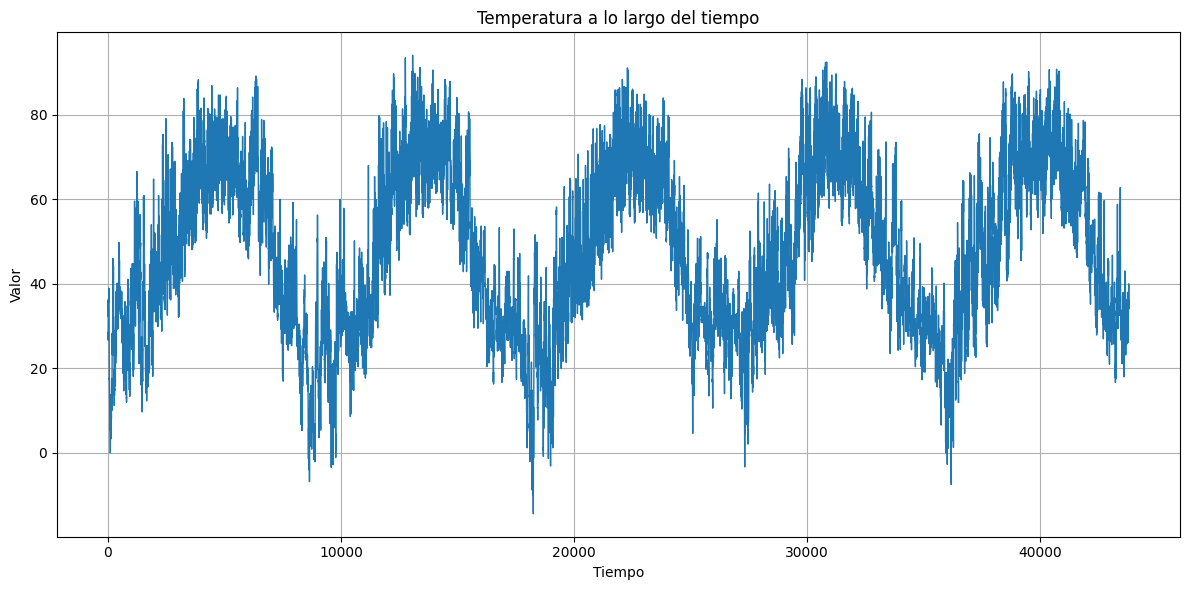


Serie visualizada correctamente.


In [39]:
df = pd.read_csv('C:\\Users\\windows\\.cache\\kagglehub\\datasets\\mubashirrahim\\wind-power-generation-data-forecasting\\versions\\1\\Location1.csv')
df = df[['temperature_2m','Time']]
df["Date"] = pd.to_datetime(df["Time"])
df['Date'] = df['Date'].sort_values(ascending=True)
df.set_index("Time", inplace=True)
df.rename(columns={"temperature_2m" : "value"}, inplace = True)
# Creamos un índice para visualizar la serie
df.index = pd.RangeIndex(start=0, stop=len(df), step=1)

# Visualizar
plt.figure(figsize=(12,6))
plt.plot(df["value"], linewidth=1)
plt.title("Temperatura a lo largo del tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nSerie visualizada correctamente.")

## Valores perdidos

In [5]:
df.isna().value_counts()

value  Date 
False  False    43800
Name: count, dtype: int64

No tiene valores perdidos la serie, se continua al siguiente inciso.

## Transformaciones

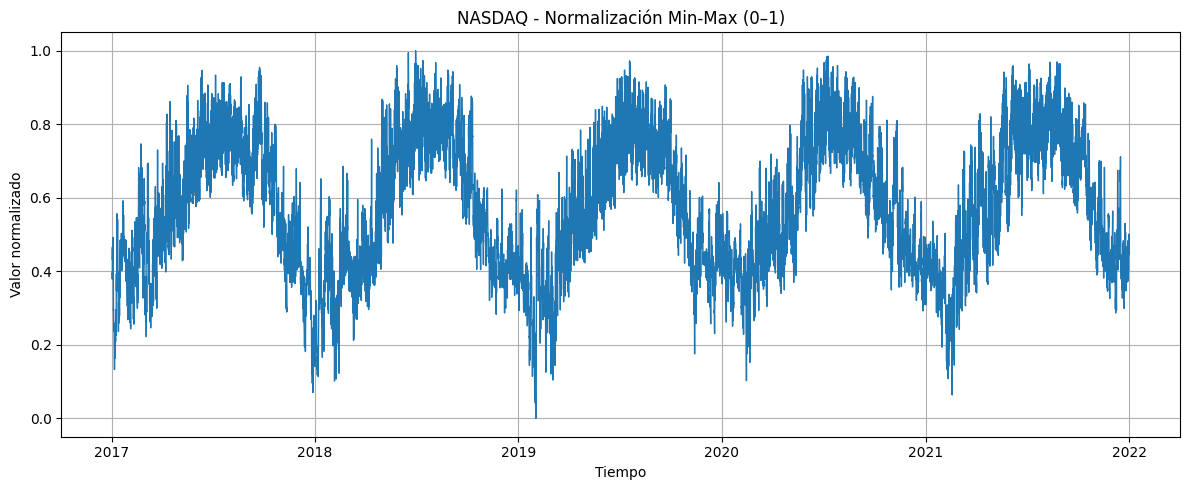

In [6]:
scaler = MinMaxScaler(feature_range=(0, 1))
s_norm = pd.Series(
    scaler.fit_transform(df['value'].values.reshape(-1, 1)).ravel(),
    index=df['Date'],
    name="nasdaq_norm_0_1"
)

plt.figure(figsize=(12, 5))
plt.plot(s_norm, linewidth=1)
plt.title("NASDAQ - Normalización Min-Max (0–1)")
plt.xlabel("Tiempo" if not isinstance(df.index, pd.DatetimeIndex) else "Fecha")
plt.ylabel("Valor normalizado")
plt.grid(True)
plt.tight_layout()
plt.show()

## Implementación de un Modelo SARIMA

Posible (p,q,d,s) = (2,1,1,24), faltaría comprobarse con la derivada.

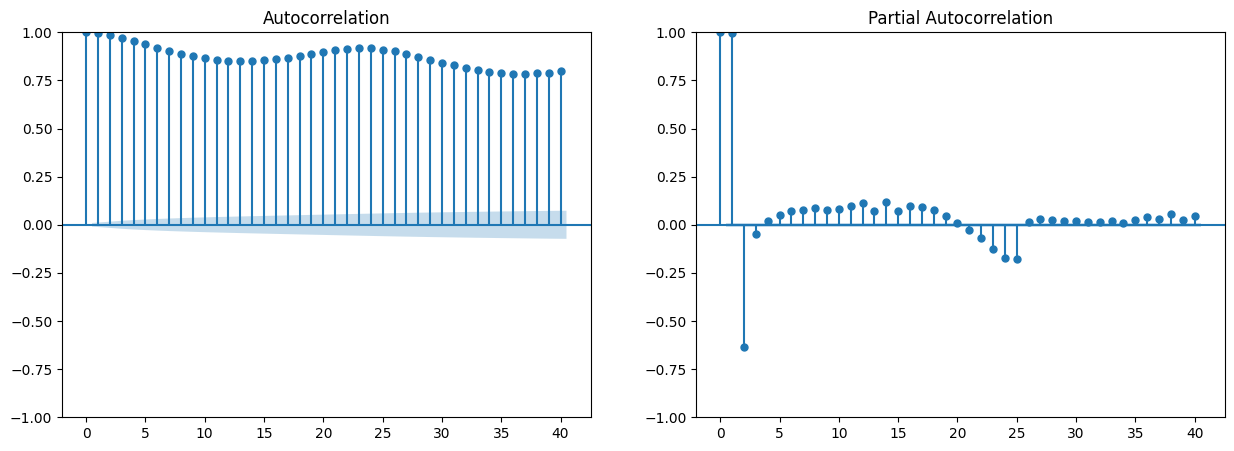

In [7]:
# Calcular matriz de correlación
corr_matrix = df.corr()
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(df['value'], lags=40, ax=ax[0])
plot_pacf(df['value'], lags=40, ax=ax[1])
plt.show()


Probemos su comportamiento con la derivada, lo que nos da un modelo (1,1,0,24)

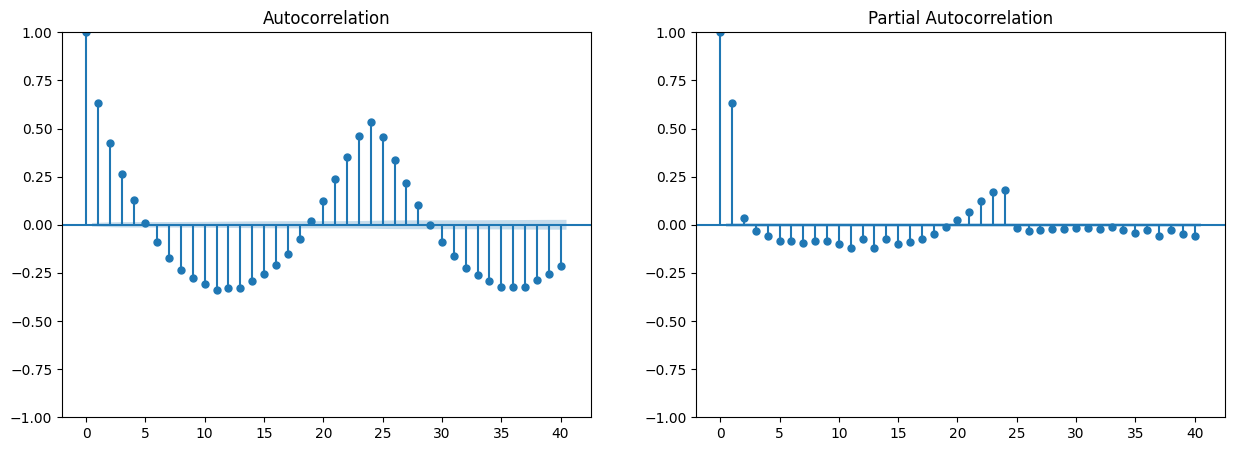

In [38]:
serie_diff = df.diff().dropna()
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(serie_diff['value'], lags=40, ax=ax[0])
plot_pacf(serie_diff['value'], lags=40, ax=ax[1])
plt.show()

In [27]:
train_size = int(len(s_norm) * 0.8)

scaler = MinMaxScaler((0,1))


train_values = df['value'].iloc[:train_size].values.reshape(-1,1)
test_values  = df['value'].iloc[train_size:].values.reshape(-1,1)

train_norm = scaler.fit_transform(train_values).ravel()
test_norm  = scaler.transform(test_values).ravel()

y_train_series = pd.Series(train_norm, index=df['Date'].iloc[:train_size], name="nasdaq_norm_0_1")
y_test_series  = pd.Series(test_norm,  index=df['Date'].iloc[train_size:],  name="nasdaq_norm_0_1")

In [ ]:
# Usar auto_arima para encontrar los mejores parámetros SARIMA
model_auto = auto_arima(
    y_train_series,
    seasonal=True,  # Indica que el modelo debe considerar estacionalidad
    m=24,  # Frecuencia estacional (por ejemplo, 12 para datos mensuales)
    trace=True,  # Muestra el progreso del ajuste
    suppress_warnings=True,  # Suprime advertencias
    stepwise=True  # Usa un enfoque paso a paso para optimizar
)

# Imprimir los mejores parámetros encontrados
print("Mejores parámetros SARIMA:", model_auto.order, "Estacional:", model_auto.seasonal_order)


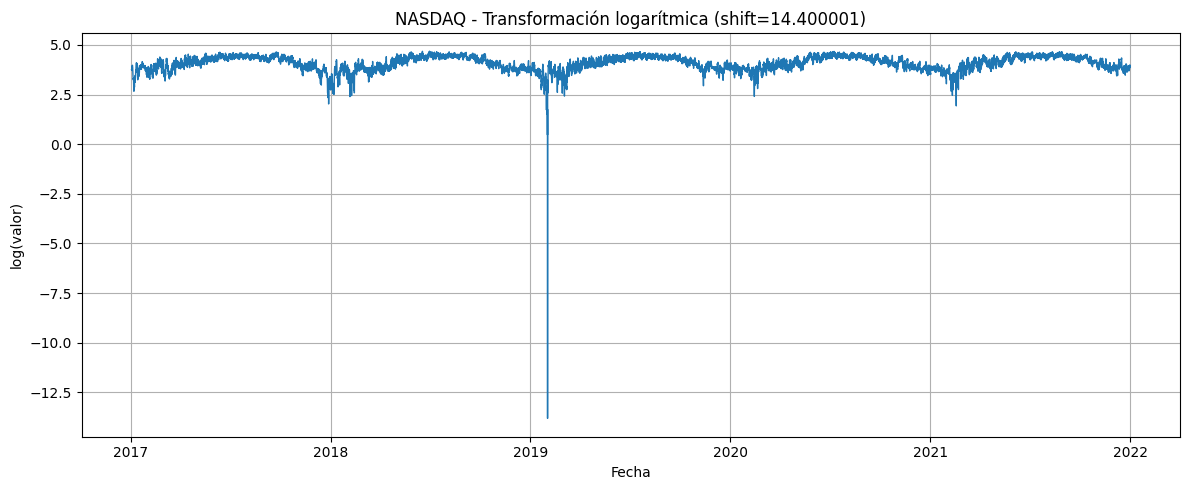

(35040,) (8760,)
Train: 2017-01-02 00:00:00 -> 2020-12-31 23:00:00
Test : 2021-01-01 00:00:00 -> 2021-12-31 23:00:00


In [59]:

df = df.copy()
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

s = df.set_index("Date")["value"].astype(float)


min_val = s.min()
shift = 0.0
if min_val <= 0:
    shift = abs(min_val) + 1e-6

s_log = np.log(s + shift)
s_log.name = "log(value_shifted)"

plt.figure(figsize=(12, 5))
plt.plot(s_log, linewidth=1)
plt.title(f"NASDAQ - Transformación logarítmica (shift={shift:.6f})")
plt.xlabel("Tiempo" if not isinstance(s.index, pd.DatetimeIndex) else "Fecha")
plt.ylabel("log(valor)")
plt.grid(True)
plt.tight_layout()
plt.show()

train_size = int(len(s_log) * 0.8)

y_train_series = s_log.iloc[:train_size]
y_test_series  = s_log.iloc[train_size:]

print(y_train_series.shape, y_test_series.shape)
print("Train:", y_train_series.index.min(), "->", y_train_series.index.max())
print("Test :", y_test_series.index.min(),  "->", y_test_series.index.max())

In [80]:
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURACIÓN DEL MODELO SARIMA(1,1,3)(2,1,1)[24]
# ============================================================
ORDER = (2,1,2)
SEASONAL_ORDER = (1,0,1,24)
TREND = 'n' # 'n' (ninguno), 'c' (constante), 't' (tendencia lineal), 'ct' (constante + tendencia)
# ============================================================
# 2. FUNCIONES DE UTILIDAD
# ============================================================
def calcular_metricas(y_real, y_pred, n_params=0, dataset_name=""):
    """Calcula métricas de evaluación para series temporales"""
    y_real = np.array(y_real).flatten()
    y_pred = np.array(y_pred).flatten()

    min_len = min(len(y_real), len(y_pred))
    y_real = y_real[:min_len]
    y_pred = y_pred[:min_len]

    n = len(y_real)

    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real, y_pred)

    smape = 100 * np.mean(2 * np.abs(y_pred - y_real) / (np.abs(y_real) + np.abs(y_pred) + 1e-10))

    ss_res = np.sum((y_real - y_pred) ** 2)
    ss_tot = np.sum((y_real - np.mean(y_real)) ** 2)
    r2 = 1 - (ss_res / (ss_tot + 1e-10))

    aic = bic = np.nan
    if n_params > 0 and n > 0:
        aic = n * np.log(mse) + 2 * n_params
        bic = n * np.log(mse) + n_params * np.log(n)

    data_range = np.max(y_real) - np.min(y_real)
    mse_percent = 100 * mse / (data_range ** 2 + 1e-10) if data_range > 0 else 0
    rmse_percent = 100 * rmse / data_range if data_range > 0 else 0

    return {
        f'MSE_{dataset_name}': mse,
        f'MSE_{dataset_name}_%': mse_percent,
        f'RMSE_{dataset_name}': rmse,
        f'RMSE_{dataset_name}_%': rmse_percent,
        f'MAE_{dataset_name}': mae,
        f'SMAPE_{dataset_name}_%': smape,
        f'R2_{dataset_name}': r2,
        f'AIC_{dataset_name}': aic,
        f'BIC_{dataset_name}': bic,
        f'n_{dataset_name}': n
    }

def forecast_sarima(modelo, y_train, steps):
    """Genera pronóstico con SARIMA"""
    try:
        fc = modelo.get_forecast(steps=steps)
        mean = fc.predicted_mean
        ci = fc.conf_int(alpha=0.05)
        low, up = ci.iloc[:, 0], ci.iloc[:, 1]

        idx_future = pd.RangeIndex(len(y_train) + 1, len(y_train) + 1 + steps)
        mean.index = idx_future
        low.index = idx_future
        up.index = idx_future

        return mean, low, up
    except Exception as e:
        print(f"Error en forecast: {e}")
        idx_future = pd.RangeIndex(len(y_train) + 1, len(y_train) + 1 + steps)
        mean = pd.Series([np.nan] * steps, index=idx_future)
        low = pd.Series([np.nan] * steps, index=idx_future)
        up = pd.Series([np.nan] * steps, index=idx_future)
        return mean, low, up

# ============================================================
# 3. ENTRENAR MODELO SARIMA
# ============================================================
print("\n" + "=" * 60)
print("ENTRENANDO MODELO SARIMA")
print("=" * 60)

print(f"Modelo: SARIMA{ORDER}{SEASONAL_ORDER[:-1]}[{SEASONAL_ORDER[-1]}] | trend='{TREND}'")

start_time_final = time.time()

modelo_final = SARIMAX(
    y_train_series,
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    trend=TREND,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=100)
'''modelo_final = SARIMAX(
    y_train_series,
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    trend=TREND,
    enforce_stationarity=False,
    enforce_invertibility=False,
    simple_differencing=True
).fit(disp=False, maxiter=100, low_memory=True)
training_time_final = time.time() - start_time_final
print(f"✓ Modelo entrenado en {training_time_final:.2f} segundos")'''

# ============================================================
# 4. PREDICCIONES Y MÉTRICAS
# ============================================================
print("\n" + "=" * 60)
print("EVALUANDO MODELO")
print("=" * 60)

# In-sample
y_train_pred = modelo_final.fittedvalues
min_len_train = min(len(y_train_series), len(y_train_pred))
y_train_actual = y_train_series.values[:min_len_train]
y_train_pred_vals = y_train_pred.values[:min_len_train]

# Out-of-sample
y_test_pred, y_test_low, y_test_up = forecast_sarima(modelo_final, y_train_series, len(y_test_series))

n_params = len(modelo_final.params)

metrics_in = calcular_metricas(y_train_actual, y_train_pred_vals, n_params, "in")
metrics_out = calcular_metricas(y_test_series.values, y_test_pred.values, n_params, "out")

print("\n★ MÉTRICAS FINALES:")
print("-" * 50)
print("IN-SAMPLE (Entrenamiento):")
print(f"  MSE: {metrics_in['MSE_in']:.6f} ({metrics_in['MSE_in_%']:.2f}%)")
print(f"  RMSE: {metrics_in['RMSE_in']:.6f} ({metrics_in['RMSE_in_%']:.2f}%)")
print(f"  MAE: {metrics_in['MAE_in']:.6f}")
print(f"  SMAPE: {metrics_in['SMAPE_in_%']:.2f}%")
print(f"  R²: {metrics_in['R2_in']:.4f}")
print(f"  AIC: {metrics_in['AIC_in']:.2f}")
print(f"  BIC: {metrics_in['BIC_in']:.2f}")

print("\nOUT-OF-SAMPLE (Prueba):")
print(f"  MSE: {metrics_out['MSE_out']:.6f} ({metrics_out['MSE_out_%']:.2f}%)")
print(f"  RMSE: {metrics_out['RMSE_out']:.6f} ({metrics_out['RMSE_out_%']:.2f}%)")
print(f"  MAE: {metrics_out['MAE_out']:.6f}")
print(f"  SMAPE: {metrics_out['SMAPE_out_%']:.2f}%")
print(f"  R²: {metrics_out['R2_out']:.4f}")
print(f"  AIC: {metrics_out['AIC_out']:.2f}")
print(f"  BIC: {metrics_out['BIC_out']:.2f}")


ENTRENANDO MODELO SARIMA
Modelo: SARIMA(2, 1, 2)(1, 0, 1)[24] | trend='n'

EVALUANDO MODELO

★ MÉTRICAS FINALES:
--------------------------------------------------
IN-SAMPLE (Entrenamiento):
  MSE: 0.011257 (0.00%)
  RMSE: 0.106098 (0.57%)
  MAE: 0.029843
  SMAPE: 0.79%
  R²: 0.9181
  AIC: -157203.23
  BIC: -157143.98

OUT-OF-SAMPLE (Prueba):
  MSE: 1.640871 (22.11%)
  RMSE: 1.280965 (47.02%)
  MAE: 1.155695
  SMAPE: 32.95%
  R²: -12.9895
  AIC: 4352.19
  BIC: 4401.73


In [82]:
# Función para aplicar la transformada inversa
def inverse_transform_log(s, shift):
    return np.exp(s) - shift

# Aplicar la transformada inversa a cada conjunto de datos
y_train_actual = inverse_transform_log(y_train_actual, shift)
y_train_pred_vals = inverse_transform_log(y_train_pred_vals, shift)
y_test_series = inverse_transform_log(y_test_series, shift)
y_test_pred = inverse_transform_log(y_test_pred, shift)
y_test_up = inverse_transform_log(y_test_up, shift)
y_test_low = inverse_transform_log(y_test_low, shift)


GENERANDO VISUALIZACIONES


Text(0.5, 0.98, 'ANÁLISIS SARIMA - NASDAQ Dataset\nModelo: SARIMA(2, 1, 2)(1, 0, 1)[24]')

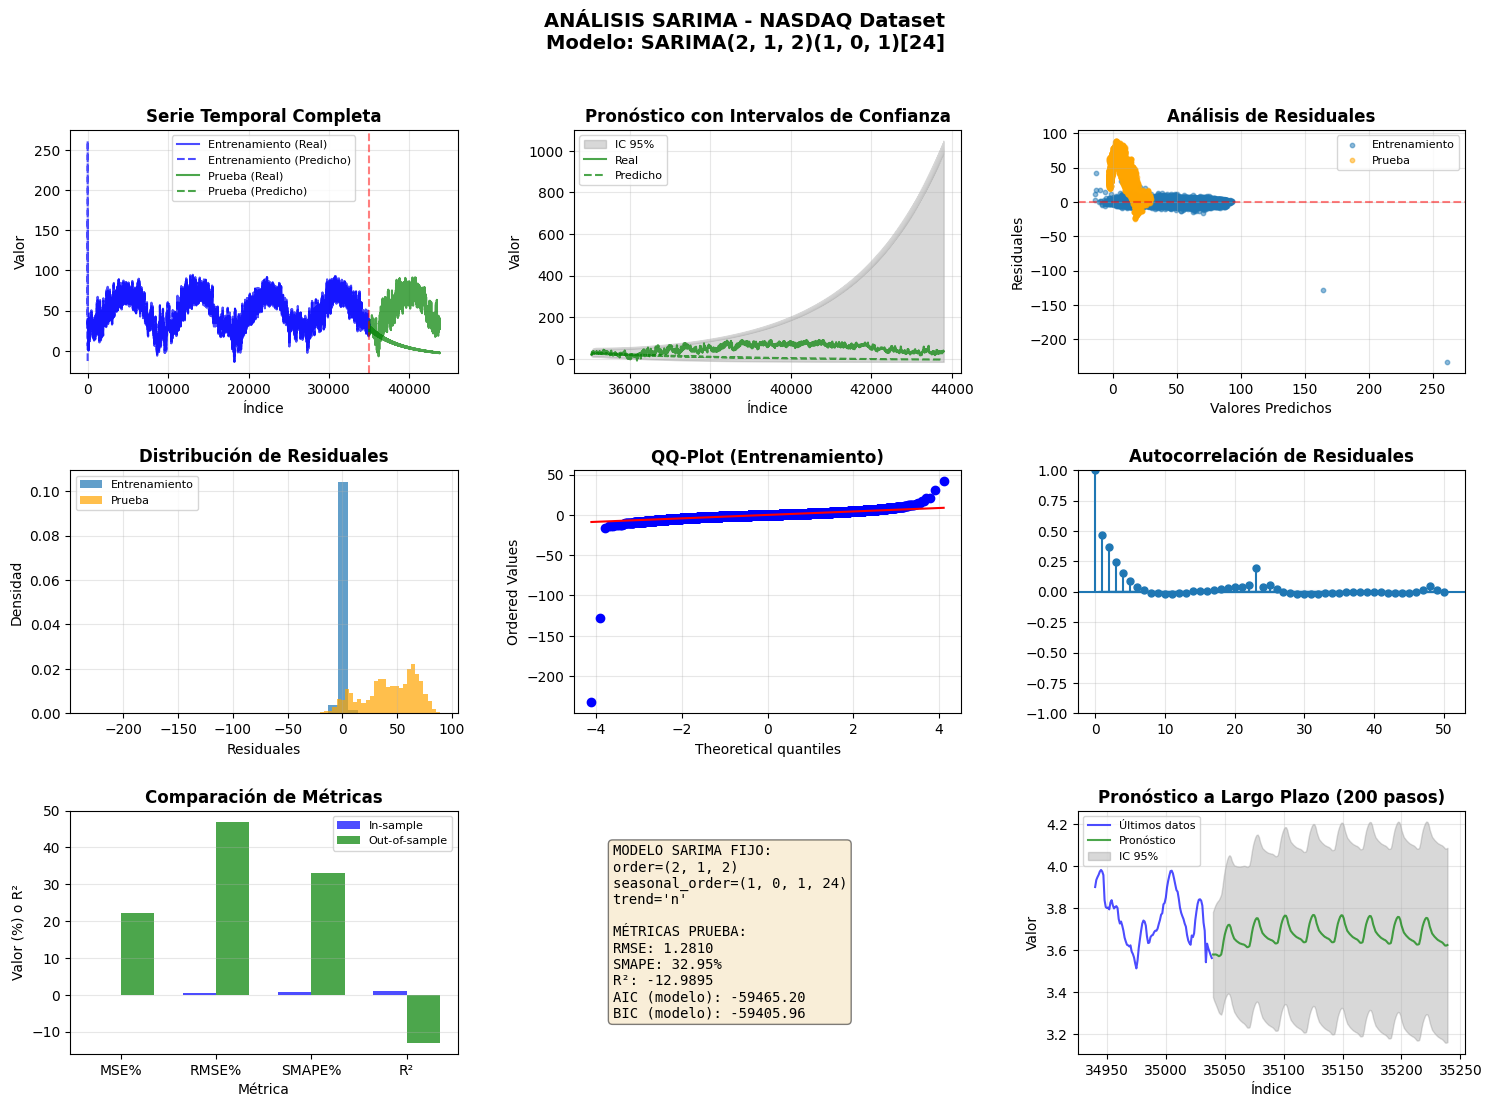

In [83]:
# ============================================================
# 5. VISUALIZACIONES
# ============================================================
print("\n" + "=" * 60)
print("GENERANDO VISUALIZACIONES")
print("=" * 60)

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Serie completa
ax1 = axes[0, 0]
ax1.plot(np.arange(len(y_train_actual)), y_train_actual, 'b-', alpha=0.7, label='Entrenamiento (Real)')
ax1.plot(np.arange(len(y_train_actual)), y_train_pred_vals, 'b--', alpha=0.7, label='Entrenamiento (Predicho)')
ax1.plot(np.arange(len(y_train_actual), len(y_train_actual) + len(y_test_series)),
         y_test_series.values, 'g-', alpha=0.7, label='Prueba (Real)')
ax1.plot(np.arange(len(y_train_actual), len(y_train_actual) + len(y_test_series)),
         y_test_pred.values, 'g--', alpha=0.7, label='Prueba (Predicho)')
ax1.axvline(x=len(y_train_actual), color='r', linestyle='--', alpha=0.5)
ax1.set_title('Serie Temporal Completa', fontweight='bold')
ax1.set_xlabel('Índice')
ax1.set_ylabel('Valor')
ax1.legend(loc='best', fontsize=8)
ax1.grid(True, alpha=0.3)

# 2. Intervalos de confianza (prueba)
ax2 = axes[0, 1]
test_idx = np.arange(len(y_train_actual), len(y_train_actual) + len(y_test_series))
ax2.fill_between(test_idx, y_test_low.values, y_test_up.values, alpha=0.3, color='gray', label='IC 95%')
ax2.plot(test_idx, y_test_series.values, 'g-', alpha=0.7, label='Real')
ax2.plot(test_idx, y_test_pred.values, 'g--', alpha=0.7, label='Predicho')
ax2.set_title('Pronóstico con Intervalos de Confianza', fontweight='bold')
ax2.set_xlabel('Índice')
ax2.set_ylabel('Valor')
ax2.legend(loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

# 3. Residuales
ax3 = axes[0, 2]
residuales_train = y_train_actual - y_train_pred_vals
residuales_test = y_test_series.values - y_test_pred.values
ax3.scatter(y_train_pred_vals, residuales_train, alpha=0.5, s=10, label='Entrenamiento')
ax3.scatter(y_test_pred.values, residuales_test, alpha=0.5, s=10, color='orange', label='Prueba')
ax3.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax3.set_title('Análisis de Residuales', fontweight='bold')
ax3.set_xlabel('Valores Predichos')
ax3.set_ylabel('Residuales')
ax3.legend(loc='best', fontsize=8)
ax3.grid(True, alpha=0.3)

# 4. Histograma de residuales
ax4 = axes[1, 0]
ax4.hist(residuales_train, bins=30, alpha=0.7, density=True, label='Entrenamiento')
ax4.hist(residuales_test, bins=30, alpha=0.7, density=True, color='orange', label='Prueba')
ax4.set_title('Distribución de Residuales', fontweight='bold')
ax4.set_xlabel('Residuales')
ax4.set_ylabel('Densidad')
ax4.legend(loc='best', fontsize=8)
ax4.grid(True, alpha=0.3)

# 5. QQ-Plot de residuales
ax5 = axes[1, 1]
stats.probplot(residuales_train, dist="norm", plot=ax5)
ax5.set_title('QQ-Plot (Entrenamiento)', fontweight='bold')
ax5.grid(True, alpha=0.3)

# 6. Autocorrelación de residuales
ax6 = axes[1, 2]
plot_acf(residuales_train, lags=50, ax=ax6, alpha=0.05)
ax6.set_title('Autocorrelación de Residuales', fontweight='bold')
ax6.grid(True, alpha=0.3)

# 7. Comparación de métricas
ax7 = axes[2, 0]
metricas_nombres = ['MSE%', 'RMSE%', 'SMAPE%', 'R²']
valores_in = [metrics_in['MSE_in_%'], metrics_in['RMSE_in_%'],
              metrics_in['SMAPE_in_%'], metrics_in['R2_in']]
valores_out = [metrics_out['MSE_out_%'], metrics_out['RMSE_out_%'],
               metrics_out['SMAPE_out_%'], metrics_out['R2_out']]

x = np.arange(len(metricas_nombres))
ancho = 0.35
ax7.bar(x - ancho/2, valores_in, ancho, label='In-sample', alpha=0.7, color='blue')
ax7.bar(x + ancho/2, valores_out, ancho, label='Out-of-sample', alpha=0.7, color='green')
ax7.set_xlabel('Métrica')
ax7.set_ylabel('Valor (%) o R²')
ax7.set_title('Comparación de Métricas', fontweight='bold')
ax7.set_xticks(x)
ax7.set_xticklabels(metricas_nombres)
ax7.legend(loc='best', fontsize=8)
ax7.grid(True, alpha=0.3, axis='y')

# 8. Parámetros del modelo
ax8 = axes[2, 1]
ax8.axis('off')
info_text = "MODELO SARIMA FIJO:\n"
info_text += f"order={ORDER}\nseasonal_order={SEASONAL_ORDER}\ntrend='{TREND}'\n"
info_text += "\nMÉTRICAS PRUEBA:\n"
info_text += f"RMSE: {metrics_out['RMSE_out']:.4f}\n"
info_text += f"SMAPE: {metrics_out['SMAPE_out_%']:.2f}%\n"
info_text += f"R²: {metrics_out['R2_out']:.4f}\n"
info_text += f"AIC (modelo): {modelo_final.aic:.2f}\n"
info_text += f"BIC (modelo): {modelo_final.bic:.2f}"
ax8.text(0.1, 0.5, info_text, fontsize=10, verticalalignment='center',
         family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 9. Pronóstico a largo plazo
ax9 = axes[2, 2]
h_largo = 200
y_largo_pred, y_largo_low, y_largo_up = forecast_sarima(modelo_final, y_train_series, h_largo)

ultimos = 100
inicio_grafico = max(len(y_train_series) - ultimos, 0)
idx_train_plot = np.arange(inicio_grafico, len(y_train_series))
idx_largo_plot = np.arange(len(y_train_series), len(y_train_series) + h_largo)

ax9.plot(idx_train_plot, y_train_series.values[inicio_grafico:], 'b-', alpha=0.7, label='Últimos datos')
ax9.plot(idx_largo_plot, y_largo_pred.values, 'g-', alpha=0.7, label='Pronóstico')
ax9.fill_between(idx_largo_plot, y_largo_low.values, y_largo_up.values,
                 alpha=0.3, color='gray', label='IC 95%')
ax9.set_title(f'Pronóstico a Largo Plazo ({h_largo} pasos)', fontweight='bold')
ax9.set_xlabel('Índice')
ax9.set_ylabel('Valor')
ax9.legend(loc='best', fontsize=8)
ax9.grid(True, alpha=0.3)

fig.suptitle(
    "ANÁLISIS SARIMA - NASDAQ Dataset\n"
    f"Modelo: SARIMA{ORDER}{SEASONAL_ORDER[:-1]}[{SEASONAL_ORDER[-1]}]",
    fontsize=14, fontweight='bold', y=0.98
)

## ARnet

In [78]:
# Se espera una columna 'value'
X_train_raw = df['value'].iloc[:train_size].values.reshape(-1,1).astype(float)
X_test_raw  = df['value'].iloc[train_size:].values.reshape(-1, 1).astype(float)
# ============================
# 2) TRANSFORMACIONES: DIFERENCIACIÓN
# ============================
def apply_differencing(series: np.ndarray, order: int = 1) -> np.ndarray:
    """Aplica diferenciación de orden 'order' (1 por defecto)."""
    diff_series = series.copy()
    for _ in range(order):
        diff_series = np.diff(diff_series, axis=0)
    return diff_series

def reconstruct_series_from_diffs(diffs: np.ndarray, first_value: float) -> np.ndarray:
    """Reconstruye la serie original a partir de diferencias y el primer valor (y0)."""
    diffs = diffs.flatten()
    reconstructed = np.zeros(len(diffs) + 1, dtype=float)
    reconstructed[0] = float(first_value)
    for i in range(1, len(reconstructed)):
        reconstructed[i] = reconstructed[i - 1] + diffs[i - 1]
    return reconstructed

# Diferenciar
X_train_diff = apply_differencing(X_train_raw, order=1)
X_test_diff  = apply_differencing(X_test_raw, order=1)

first_value_train = float(X_train_raw[0, 0])
first_value_test  = float(X_test_raw[0, 0])

print("\nDespués de diferenciación:")
print(f"Entrenamiento: {X_train_diff.shape}")
print(f"Prueba: {X_test_diff.shape}")

# ============================
# 3) PREPARAR DATOS AUTOREGRESIVOS (INPUT DELAYS)
# ============================
def create_autoregressive_data(data: np.ndarray, delays: list[int], target: np.ndarray | None = None):
    """
    Crea dataset con retrasos temporales:
    X[t] = [x(t-d1), x(t-d2), ...]
    y[t] = target[t]
    """
    max_delay = max(delays)
    X_delayed = []

    for i in range(max_delay, len(data)):
        delayed_values = []
        for d in sorted(delays):
            delayed_values.extend(data[i - d])
        X_delayed.append(delayed_values)

    X_delayed = np.array(X_delayed, dtype=float)

    if target is not None:
        y = target[max_delay:]
        return X_delayed, y

    return X_delayed

# ============================
# 4) NORMALIZACIÓN
# ============================
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_diff)
X_test_scaled  = scaler.transform(X_test_diff)

T_train_scaled = X_train_scaled.copy()
T_test_scaled  = X_test_scaled.copy()

# ============================
# 5) MODELO
# ============================
fixed_params = {
    "input_delays": [1, 2],
    "hidden_layer_sizes": (20, 10, 20),
    "activation": "relu",
    "solver": "lbfgs",
    "alpha": 0.01,
    "learning_rate_init": 1,
    "max_iter": 500,
}

# Preparar entrenamiento con retrasos
X_train_delayed, y_train = create_autoregressive_data(
    X_train_scaled, fixed_params["input_delays"], T_train_scaled
)

X_test_delayed, y_test = create_autoregressive_data(
    X_test_scaled, fixed_params["input_delays"], T_test_scaled
)

print("\nDatos con retrasos:")
print(f"  Train X: {X_train_delayed.shape} | Train y: {y_train.shape}")
print(f"  Test  X: {X_test_delayed.shape} | Test  y: {y_test.shape}")

# Entrenar MLPRegressor
arnet = MLPRegressor(
    hidden_layer_sizes=fixed_params["hidden_layer_sizes"],
    activation=fixed_params["activation"],
    solver=fixed_params["solver"],
    alpha=fixed_params["alpha"],
    learning_rate_init=fixed_params["learning_rate_init"],
    max_iter=fixed_params["max_iter"],
    random_state=42,
    verbose=0
)

print("\nEntrenando modelo ARNet (MLPRegressor)...")
t0 = time.time()
arnet.fit(X_train_delayed, y_train.ravel())
train_time = time.time() - t0
print(f"Entrenamiento completado en {train_time:.2f} s")

# ============================
# 6) MÉTRICAS
# ============================
def calculate_metrics(y_true, y_pred, n_params, dataset_name=""):
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    min_len = min(len(y_true), len(y_pred))
    y_true = y_true[:min_len]
    y_pred = y_pred[:min_len]
    n = len(y_true)

    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)

    smape = 100 * np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-10)
    )

    corr = np.corrcoef(y_true, y_pred)
    r2 = float(corr[0, 1] ** 2) if np.isfinite(corr[0, 1]) else np.nan

    aic = n * np.log(mse + 1e-12) + 2 * n_params
    bic = n * np.log(mse + 1e-12) + n_params * np.log(max(n, 2))

    data_range = np.max(y_true) - np.min(y_true)
    mse_percent = 100 * mse / (data_range ** 2 + 1e-10)
    rmse_percent = 100 * rmse / (data_range + 1e-10)

    return {
        f"MSE_{dataset_name}": mse,
        f"MSE_{dataset_name}_%": mse_percent,
        f"RMSE_{dataset_name}": rmse,
        f"RMSE_{dataset_name}_%": rmse_percent,
        f"SMAPE_{dataset_name}_%": smape,
        f"R2_{dataset_name}_Pearson2": r2,
        f"AIC_{dataset_name}": aic,
        f"BIC_{dataset_name}": bic,
    }

# Número de parámetros real del MLP (calculado)
n_params_real = int(
    sum(np.prod(w.shape) for w in arnet.coefs_) + sum(np.prod(b.shape) for b in arnet.intercepts_)
)
print(f"Número de parámetros (calculado): {n_params_real}")

# Predicciones (en serie diferenciada-escalada)
y_train_pred = arnet.predict(X_train_delayed)
y_test_pred  = arnet.predict(X_test_delayed)

metrics_in  = calculate_metrics(y_train.ravel(), y_train_pred, n_params_real, "in")
metrics_out = calculate_metrics(y_test.ravel(),  y_test_pred,  n_params_real, "out")

# ============================
# 7) INVERTIR TRANSFORMACIONES PARA ANÁLISIS EN ESCALA ORIGINAL
# ============================
# Desescalar diferencias
y_train_true_descaled = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
y_train_pred_descaled = scaler.inverse_transform(y_train_pred.reshape(-1, 1)).flatten()

y_test_true_descaled = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_test_pred_descaled = scaler.inverse_transform(y_test_pred.reshape(-1, 1)).flatten()

# Reconstrucción a serie original (ojo: por delays se pierde max_delay al inicio)
max_delay = max(fixed_params["input_delays"])

# Para que la reconstrucción sea consistente, necesitamos el valor "inicial" del punto donde empieza el target.
# Como y[t] corresponde a X_scaled[t], y empieza en índice max_delay, el valor inicial real es:
train_first_value_recon = float(X_train_raw[max_delay, 0])
test_first_value_recon  = float(X_test_raw[max_delay, 0])

train_series_true = reconstruct_series_from_diffs(y_train_true_descaled, train_first_value_recon)
train_series_pred = reconstruct_series_from_diffs(y_train_pred_descaled, train_first_value_recon)

test_series_true = reconstruct_series_from_diffs(y_test_true_descaled, test_first_value_recon)
test_series_pred = reconstruct_series_from_diffs(y_test_pred_descaled, test_first_value_recon)



Después de diferenciación:
Entrenamiento: (35039, 1)
Prueba: (8759, 1)

Datos con retrasos:
  Train X: (35037, 2) | Train y: (35037, 1)
  Test  X: (8757, 2) | Test  y: (8757, 1)

Entrenando modelo ARNet (MLPRegressor)...
Entrenamiento completado en 0.63 s
Número de parámetros (calculado): 511


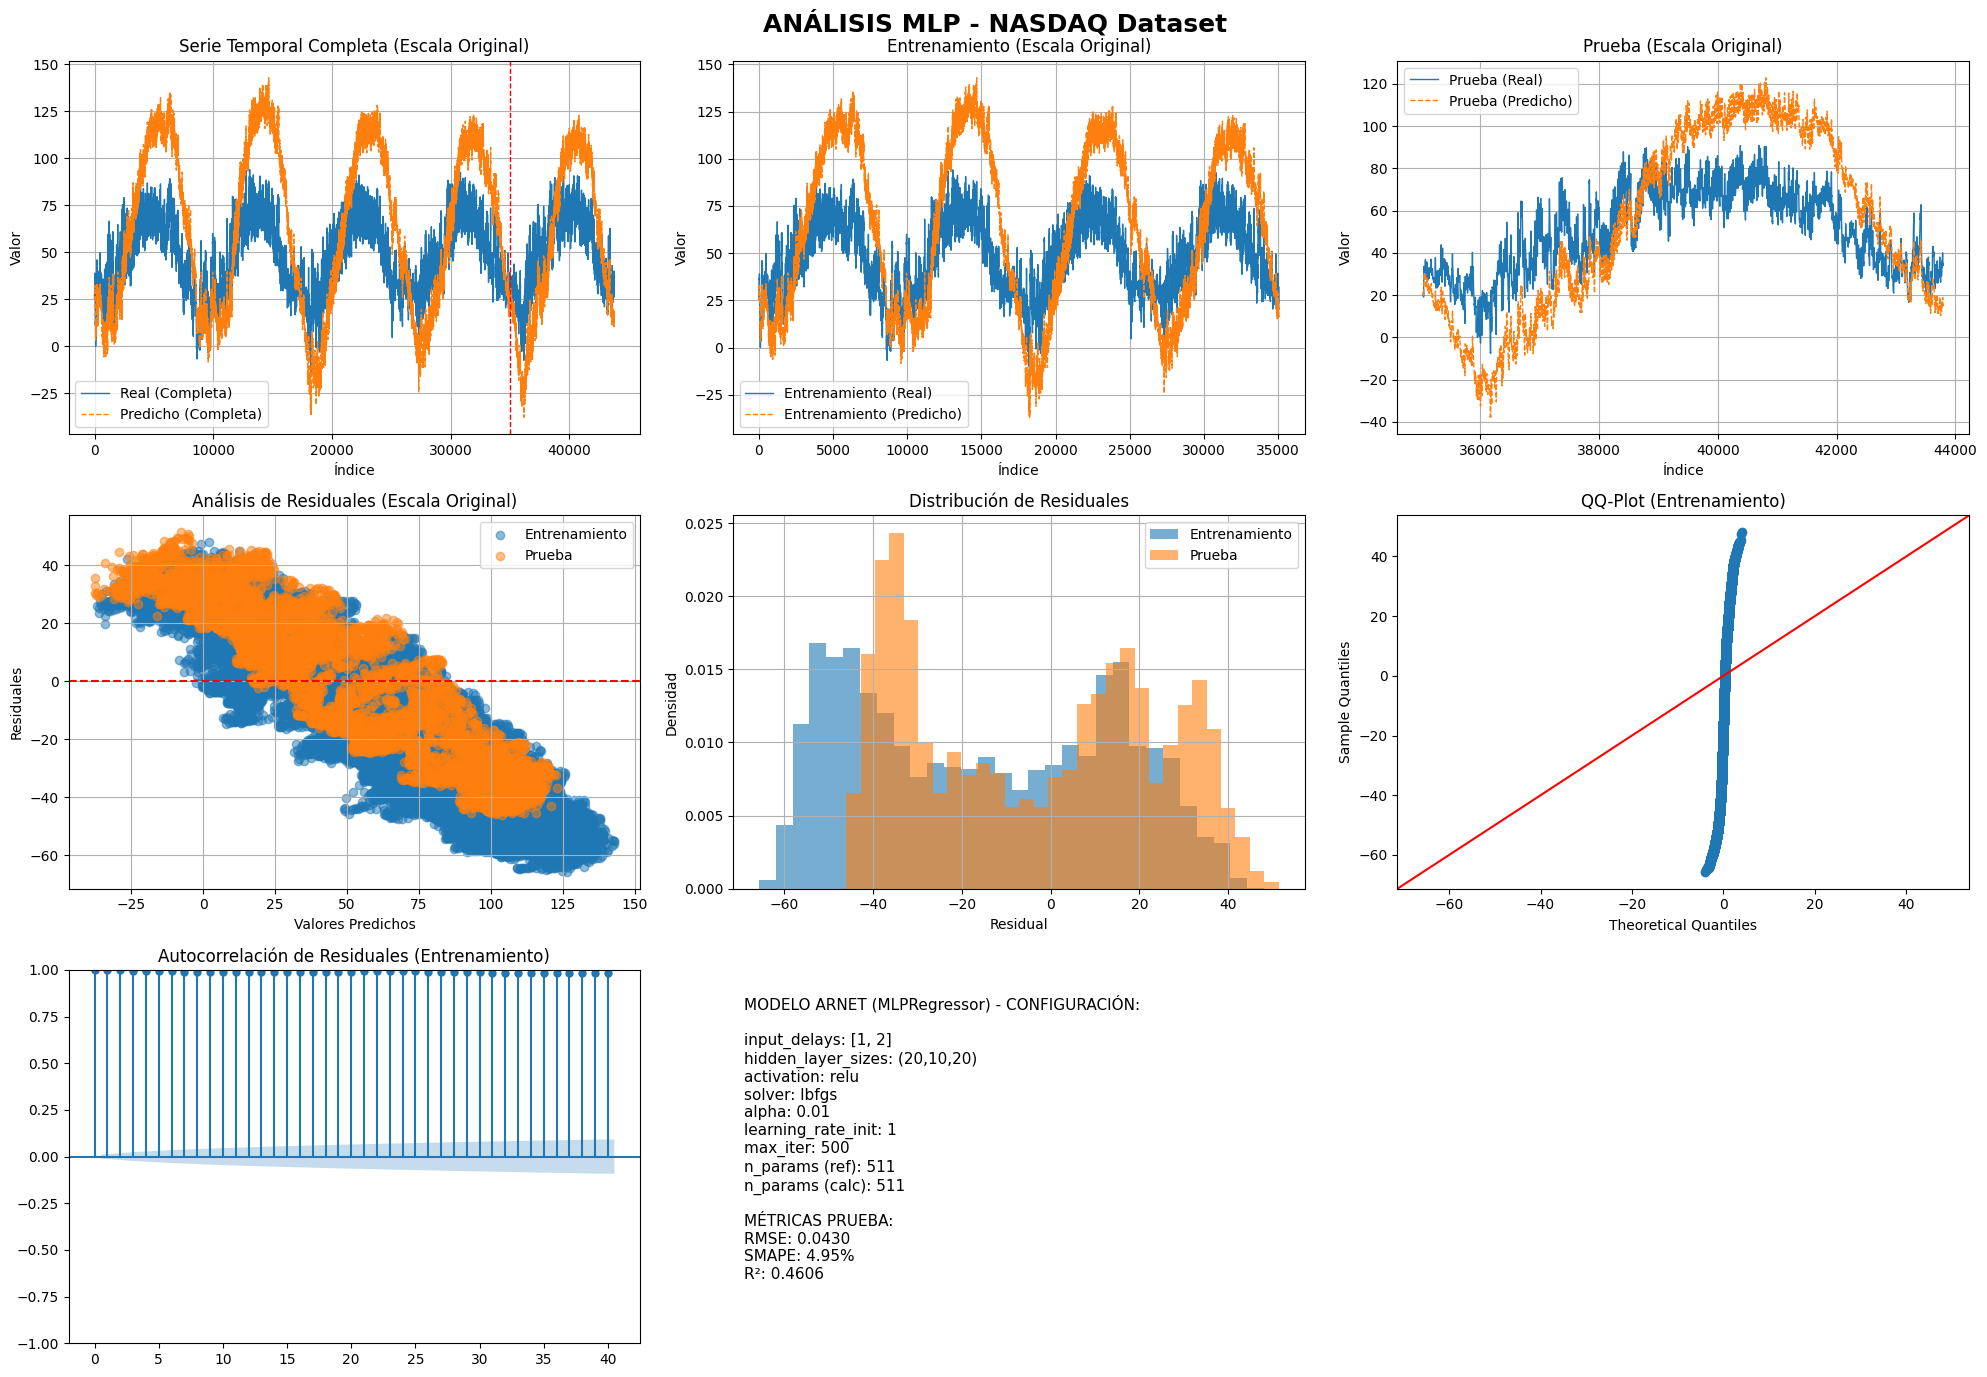


Modelo guardado: arnet_model_fixed.pkl
Scaler guardado: arnet_scaler_fixed.pkl
Métricas guardadas: arnet_model_metrics_fixed.txt

Listo.


In [79]:
# ============================
# 8) GRÁFICAS - ESCALA ORIGINAL
# ============================
# ----------------------------
# Construir ejes de índice
# ----------------------------
n_tr = len(train_series_true)
n_te = len(test_series_true)

idx_tr = np.arange(0, n_tr)
idx_te = np.arange(n_tr, n_tr + n_te)

# Para serie completa (concatenada)
series_true_full = np.concatenate([train_series_true, test_series_true])
series_pred_full = np.concatenate([train_series_pred, test_series_pred])
idx_full = np.arange(0, len(series_true_full))

# ----------------------------
# Residuales EN ESCALA ORIGINAL
# ----------------------------
res_train_orig = train_series_true - train_series_pred
res_test_orig  = test_series_true  - test_series_pred

# Métricas a mostrar (ya calculadas)
rmse_test  = metrics_out["RMSE_out"]
smape_test = metrics_out["SMAPE_out_%"]
r2_test    = metrics_out["R2_out_Pearson2"]

# ----------------------------
# Figura tipo dashboard (3x3)
# ----------------------------
fig = plt.figure(figsize=(20, 14))
plt.suptitle("ANÁLISIS MLP - NASDAQ Dataset", fontsize=18, fontweight="bold")

# ------------------------------------------------
# (1) Serie completa (original) + split marker
# ------------------------------------------------
ax1 = plt.subplot(3, 3, 1)
ax1.plot(idx_full, series_true_full, label="Real (Completa)", linewidth=1)
ax1.plot(idx_full, series_pred_full, label="Predicho (Completa)", linestyle="--", linewidth=1)
ax1.axvline(n_tr - 1, linestyle="--", color="red", linewidth=1)  # frontera train/test
ax1.set_title("Serie Temporal Completa (Escala Original)")
ax1.set_xlabel("Índice")
ax1.set_ylabel("Valor")
ax1.legend()
ax1.grid(True)

# ------------------------------------------------
# (2) Entrenamiento separado
# ------------------------------------------------
ax2 = plt.subplot(3, 3, 2)
ax2.plot(idx_tr, train_series_true, label="Entrenamiento (Real)", linewidth=1)
ax2.plot(idx_tr, train_series_pred, label="Entrenamiento (Predicho)", linestyle="--", linewidth=1)
ax2.set_title("Entrenamiento (Escala Original)")
ax2.set_xlabel("Índice")
ax2.set_ylabel("Valor")
ax2.legend()
ax2.grid(True)

# ------------------------------------------------
# (3) Prueba separado
# ------------------------------------------------
ax3 = plt.subplot(3, 3, 3)
ax3.plot(idx_te, test_series_true, label="Prueba (Real)", linewidth=1)
ax3.plot(idx_te, test_series_pred, label="Prueba (Predicho)", linestyle="--", linewidth=1)
ax3.set_title("Prueba (Escala Original)")
ax3.set_xlabel("Índice")
ax3.set_ylabel("Valor")
ax3.legend()
ax3.grid(True)

# ------------------------------------------------
# (4) Análisis de residuales (Predicho vs Residual) - ORIGINAL
# ------------------------------------------------
ax4 = plt.subplot(3, 3, 4)
ax4.scatter(train_series_pred, res_train_orig, alpha=0.5, label="Entrenamiento")
ax4.scatter(test_series_pred,  res_test_orig,  alpha=0.5, label="Prueba")
ax4.axhline(0, linestyle="--", color="red")
ax4.set_title("Análisis de Residuales (Escala Original)")
ax4.set_xlabel("Valores Predichos")
ax4.set_ylabel("Residuales")
ax4.legend()
ax4.grid(True)

# ------------------------------------------------
# (5) Distribución de residuales - ORIGINAL
# ------------------------------------------------
ax5 = plt.subplot(3, 3, 5)
ax5.hist(res_train_orig, bins=30, alpha=0.6, label="Entrenamiento", density=True)
ax5.hist(res_test_orig,  bins=30, alpha=0.6, label="Prueba", density=True)
ax5.set_title("Distribución de Residuales")
ax5.set_xlabel("Residual")
ax5.set_ylabel("Densidad")
ax5.legend()
ax5.grid(True)

# ------------------------------------------------
# (6) QQ-Plot (Entrenamiento) - ORIGINAL
# ------------------------------------------------
ax6 = plt.subplot(3, 3, 6)
sm.qqplot(res_train_orig, line="45", ax=ax6)
ax6.set_title("QQ-Plot (Entrenamiento)")

# ------------------------------------------------
# (7) ACF de residuales (Entrenamiento) - ORIGINAL
# ------------------------------------------------
ax7 = plt.subplot(3, 3, 7)
plot_acf(res_train_orig, ax=ax7, lags=40)
ax7.set_title("Autocorrelación de Residuales (Entrenamiento)")

# ------------------------------------------------
# (8) Cuadro de métricas / configuración
# ------------------------------------------------
ax8 = plt.subplot(3, 3, 8)
ax8.axis("off")
text_metrics = f"""
MODELO ARNET (MLPRegressor) - CONFIGURACIÓN:

input_delays: [1, 2]
hidden_layer_sizes: (20,10,20)
activation: relu
solver: lbfgs
alpha: 0.01
learning_rate_init: 1
max_iter: 500
n_params (ref): 511
n_params (calc): {n_params_real}

MÉTRICAS PRUEBA:
RMSE: {rmse_test:.4f}
SMAPE: {smape_test:.2f}%
R²: {r2_test:.4f}
"""
ax8.text(0.02, 0.98, text_metrics, fontsize=11, va="top")


plt.tight_layout()
plt.show()

# ============================
# 10) GUARDAR MODELO Y RESULTADOS
# ============================
joblib.dump(arnet, "arnet_model_fixed.pkl")
joblib.dump(scaler, "arnet_scaler_fixed.pkl")
print("\nModelo guardado: arnet_model_fixed.pkl")
print("Scaler guardado: arnet_scaler_fixed.pkl")

with open("arnet_model_metrics_fixed.txt", "w", encoding="utf-8") as f:
    f.write("=== MODELO ARNET (MLPRegressor) ===\n")
    for k, v in fixed_params.items():
        f.write(f"{k}: {v}\n")
    f.write(f"n_params_calculado: {n_params_real}\n")
    f.write(f"training_time_s: {train_time:.4f}\n\n")

    f.write("=== MÉTRICAS IN-SAMPLE (ENTRENAMIENTO) ===\n")
    for k, v in metrics_in.items():
        f.write(f"{k}: {v}\n")

    f.write("\n=== MÉTRICAS OUT-OF-SAMPLE (PRUEBA) ===\n")
    for k, v in metrics_out.items():
        f.write(f"{k}: {v}\n")

print("Métricas guardadas: arnet_model_metrics_fixed.txt")

print("\nListo.")

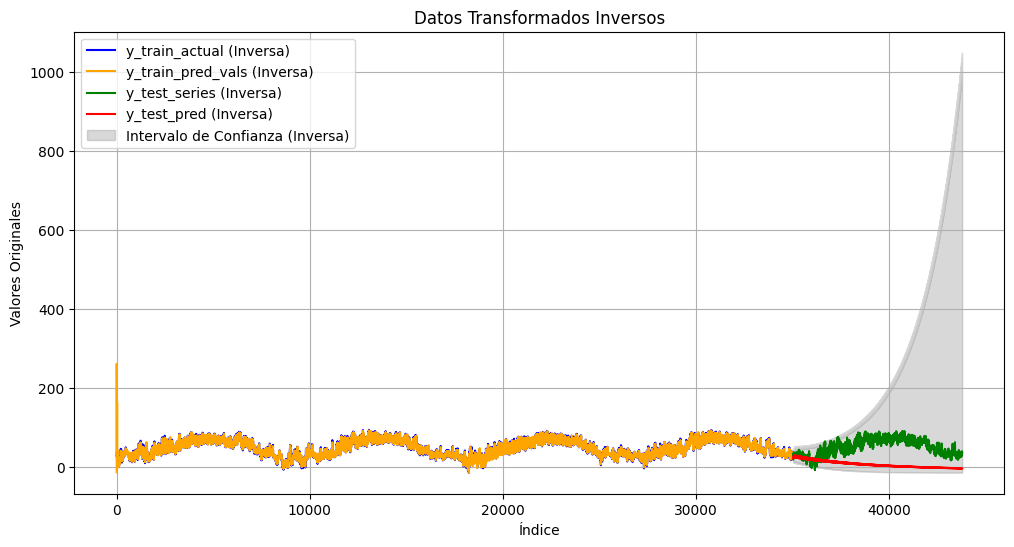

In [ ]:
# Transformada inversa para los datos escalados
import numpy as np
import matplotlib.pyplot as plt



# Graficar los datos
plt.figure(figsize=(12, 6))

# Gráfico de entrenamiento
plt.plot(y_train_actual_inv, label='y_train_actual (Inversa)', color='blue')
plt.plot(y_train_pred_vals_inv, label='y_train_pred_vals (Inversa)', color='orange')

# Gráfico de prueba
plt.plot(range(len(y_train_actual_inv), len(y_train_actual_inv) + len(y_test_series_inv)), y_test_series_inv, label='y_test_series (Inversa)', color='green')
plt.plot(range(len(y_train_actual_inv), len(y_train_actual_inv) + len(y_test_pred_inv)), y_test_pred_inv, label='y_test_pred (Inversa)', color='red')
plt.fill_between(
    range(len(y_train_actual_inv), len(y_train_actual_inv) + len(y_test_up_inv)),
    y_test_low_inv, y_test_up_inv, color='gray', alpha=0.3, label='Intervalo de Confianza (Inversa)'
)

# Configuración del gráfico
plt.title('Datos Transformados Inversos')
plt.xlabel('Índice')
plt.ylabel('Valores Originales')
plt.legend()
plt.grid()
plt.show()